## Schrödinger equation with non-autonomous potential and semilinear term

We consider the time-dependent Gross-Pitaevskii equation is given by
$$
i\partial_t \psi(x,t) = H(x,t)\psi(x,t), \quad \quad \psi(x,0) = \psi_0(x) \quad \quad t \in [0,T], \quad x \in D = [-L,L],
$$
where the time-dependent Hamiltonian $H(x,t)$ is in the form

$$
H(x,t) = \partial_x^2 + V(x, t) + g|\psi|^2, 
$$

with the potential $V(x,t) = V_0(x) + u(t)x$ containing an external potential (laser profile stating as the control in quantum optimal control see for instance \cite{IK2016}). 
In this first case, we consider the internal potential $V_0$ and the laser profile $u(t)$ to be given by

$$
V_0(x) = x^4 - 10 x^2, \quad u(t) = c \sin(\omega t), ~~ c =-10^2, ~~ \omega = 5\pi. 
$$

We consider as initial state a Gauss wave-packet given by

$$
\psi_0(x) = e^{-\frac{(x-x0)^2}{2\sigma^2}}, \quad \sigma = 0.5, \quad x_0 = -2
$$

We have to solve the following system

$$
\partial_t \psi(t) = A(t)\psi(t), \quad \psi(0) = \psi_0, \quad A(t) = -i H(t)
$$



In [2]:
import scipy as sp
from scipy.sparse.linalg import expm
from scipy.integrate import quad
from scipy.sparse import diags, eye, csc_matrix
from scipy.sparse.linalg import spsolve
from fractions import Fraction as frac

import numpy as np
from numpy import linalg as la

import math
import time
import pickle
import pandas as pd
import matplotlib.pyplot as plt

import expsolve as es
import expsolve.fourier as fe

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # embed TrueType (acceptable)
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False  # avoid LaTeX->Type3 in figures



SMALL_SIZE  = 15
MEDIUM_SIZE = 18
BIGGER_SIZE = 20
legend_size = 10

plt.rc('font', size=MEDIUM_SIZE)         # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=legend_size)   # legend fontsize

In [2]:
# -------------------------------
# Problem setup (edit as you like)
# -------------------------------
n     = 256            # spatial grid points (power of 2 is nice for spectral)
L     = 10.0           # half-domain size; domain = [-L, L]
T     = 2.0            # final time
N     = 500            # time steps
g_set = [0.0, 0.5, 2.0, 10.0, 20.0]
ωc    = 1.0            # control frequency
uc    = 0.2            # control amplitude

In [3]:
xr = [-L, L]
x  = fe.grid1d(n, xr)                 # equidistant grid
try:
    D2 = fe.diffmatrix(2, n, xr)
except Exception:
    dx = (2*L)/n
    main = -2*np.ones(n)
    off = np.ones(n-1)
    D2 = diags([off, main, off], [-1,0,1]).tocsc() / (dx*dx)

K = (-0.5) * D2

def V_trap(x):
    return x**4 - 10*x**2

def W_op(x):
    return 5 * x**2

V = diags(V_trap(x), 0).tocsc()
W = diags(W_op(x), 0).tocsc()

def u_of_t(t):
    return uc*np.sin(ωc*t)

def gaussian_packet(x, x0=0.0, sigma=1.0):
    norm = (1.0/(np.pi*sigma**2))**0.25
    return norm*np.exp(-0.5*((x-x0)/sigma)**2)

ψ0 = gaussian_packet(x)

# Utility: normalize (keep L2 norm = 1)
def normalize(psi):
    psi = np.asarray(psi).reshape(-1)
    return psi / (fe.l2norm(psi) + 1e-15)


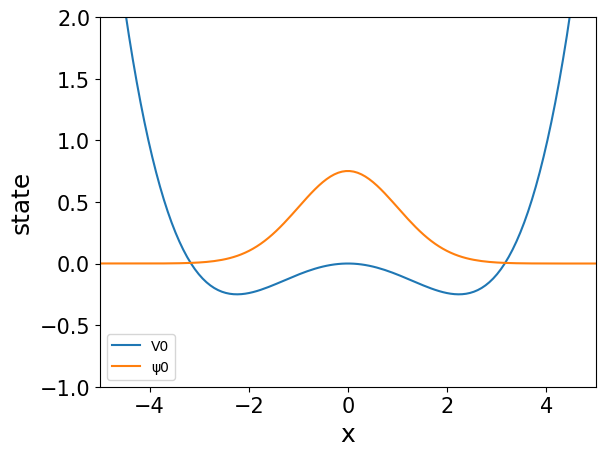

In [4]:
V0 = V_trap(x)



plt.plot(x, V0/100)
plt.plot(x, np.real(ψ0))
plt.xlim(-5,5)
plt.ylim(-1,2)
plt.xlabel('x')
plt.ylabel('state')
plt.legend(['V0','ψ0'])
plt.show()

In [5]:
# ----------------
# Algebraic setup
# ----------------
def A_of_t_psi(t, psi, g):
    Hlin = K + V + u_of_t(t)*W
    diag_nl = diags(g*np.abs(psi)**2, 0)
    return (-1j) * (Hlin + diag_nl)

def exp_apply(A, psi, h):
    psi = np.asarray(psi).reshape(-1)
    A_dense = A.toarray() if sp.sparse.issparse(A) else A
    y = A_dense @ psi if h == 1.0 else expm(h * A_dense) @ psi
    return np.asarray(y).reshape(-1)

def cayley_apply(A, psi, h):
    psi = np.asarray(psi).reshape(-1)
    I   = eye(A.shape[0], format='csc')
    lhs = (I + 0.5*h*A)
    rhs = (I - 0.5*h*A) @ psi
    rhs = np.asarray(rhs).reshape(-1)   # <-- ensure (n,)
    y   = spsolve(lhs, rhs)
    return np.asarray(y).reshape(-1)

def commutator(A, B):
    return A @ B - B @ A

In [6]:
# -----------------------------------
# Lagrange interpolation (order 4)
# -----------------------------------
x1 = 0.5 - np.sqrt(3)/6
x2 = 0.5 + np.sqrt(3)/6

def lagrange_coeffs(t_nodes, t_eval):
    t_nodes = np.asarray(t_nodes)
    m = len(t_nodes)
    w = np.ones(m)
    for j in range(m):
        for k in range(m):
            if j != k:
                w[j] /= (t_nodes[j] - t_nodes[k])
    if any(abs(t_eval - t_nodes) < 1e-15):
        e = np.zeros(m)
        e[np.argmin(abs(t_eval - t_nodes))] = 1.0
        return e
    num = np.array([w[j]/(t_eval - t_nodes[j]) for j in range(m)])
    return num/np.sum(num)

def interpolate_psi(t_nodes, psi_nodes, t_eval):
    coeffs = lagrange_coeffs(t_nodes, t_eval)                                     # shape (m,)
    # Make a (n, m) matrix with columns = psi_nodes[j]
    Psi = np.column_stack([np.asarray(v).reshape(-1) for v in psi_nodes])
    y = Psi @ coeffs                                                              # shape (n,)
    return np.asarray(y).reshape(-1)

In [7]:
# ----------------------------
# 1. CaylPol (CF–Cayley, 4th)
# ----------------------------
alpha11 = 2**(1/3)/3 + 2**(2/3)/6 + 2/3
alpha12 = alpha11 - alpha11**2
alpha21 = 1 - 2*alpha11
alpha22 = 0.0
alpha31 = alpha11
alpha32 = -alpha12

def caylpol_step(t, h, psi, g, t_hist, psi_hist):
    psi = np.asarray(psi).reshape(-1)
    p1 = interpolate_psi(t_hist, psi_hist, t + h*x1)
    p2 = interpolate_psi(t_hist, psi_hist, t + h*x2)
    A1 = A_of_t_psi(t + h*x1, p1, g)
    A2 = A_of_t_psi(t + h*x2, p2, g)
    H1 = alpha11*A1 + alpha12*A2
    H2 = alpha21*A1 + alpha22*A2
    H3 = alpha31*A1 + alpha32*A2
    y = psi
    y = cayley_apply(H3, y, h)
    y = cayley_apply(H2, y, h)
    y = cayley_apply(H1, y, h)
    return normalize(y)

In [8]:
def rkmk4_step(t, h, psi, g):
    psi = np.asarray(psi).reshape(-1)
    A1 = A_of_t_psi(t, psi, g)
    y1 = exp_apply(A1, psi, 0.5*h)
    A2 = A_of_t_psi(t + 0.5*h, y1, g)
    y2 = exp_apply(A2, psi, 0.5*h)
    A3 = A_of_t_psi(t + 0.5*h, y2, g)
    y3 = exp_apply(A3, psi, h)
    A4 = A_of_t_psi(t + h, y3, g)
    Aeff = (A1 + 2*A2 + 2*A3 + A4)/6.0
    y = exp_apply(Aeff, psi, h)
    return normalize(y)

In [9]:
# -----------------------------
# Propagation driver (generic)
# -----------------------------
def propagate(method, psi0, g, T, N):
    h = T/N
    t = 0.0
    # history for CaylPol
    psi = np.asarray(psi0).reshape(-1)
    t_hist   = [t - 3*h, t - 2*h, t - h, t]
    psi_hist = [psi.copy(), psi.copy(), psi.copy(), psi.copy()]
    for _ in range(N):
        if method == 'caylpol':
            psi = caylpol_step(t, h, psi, g, t_hist, psi_hist)
        elif method == 'nmag-free':
            psi = nmag4_free_step(t, h, psi, g)
        elif method == 'nmag-comm':
            psi = nmag4_comm_step(t, h, psi, g)
        elif method == 'rkmk4':
            psi = rkmk4_step(t, h, psi, g)
        else:
            raise ValueError("Unknown method.")
        t += h
        psi = np.asarray(psi).reshape(-1)
        t_hist   = t_hist[1:]   + [t]
        psi_hist = psi_hist[1:] + [psi.copy()]
    return psi

In [10]:
# -----------------------------
# Timing benchmark
# -----------------------------
def time_one(method, psi0, g, T, N):
    t0 = time.perf_counter()
    psiT = propagate(method, psi0, g, T, N)
    t1 = time.perf_counter()
    return psiT, (t1 - t0)

In [11]:
g0 = 1.0
psiT_cfc, t_cfc = time_one('caylpol', ψ0, g0, T, N)
psiT_rkmk, t_rkmk = time_one('rkmk4', ψ0, g0, T, N);

/home/bwembe/miniconda3/envs/Boris/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:214: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  warn('spsolve requires A be CSC or CSR matrix format',


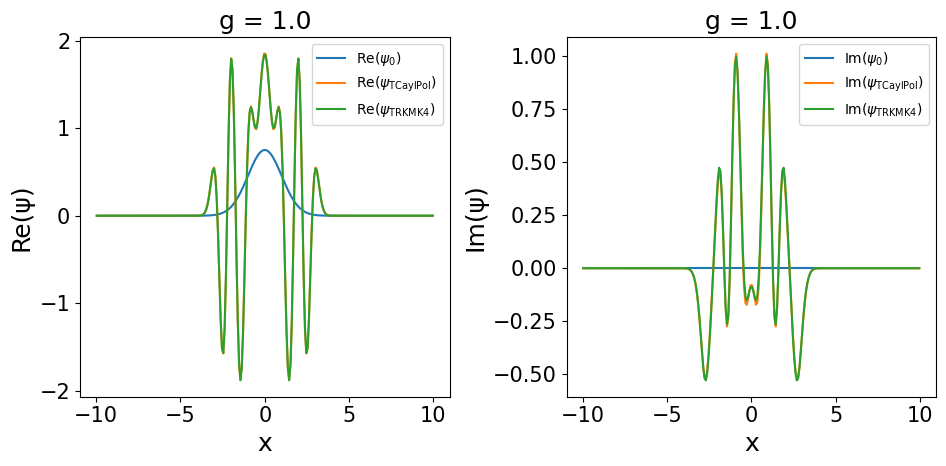

In [25]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(x, np.real(ψ0), label=r'$\mathrm{Re}(\psi_0)$')
plt.plot(x, np.real(psiT_cfc), label=r'$\mathrm{Re}(\psi_{\mathrm{TCaylPol}})$')
plt.plot(x, np.real(psiT_rkmk), label=r'$\mathrm{Re}(\psi_{\mathrm{TRKMK4}})$')
plt.xlabel('x'); plt.ylabel('Re(ψ)'); plt.legend(); plt.title('g = 1.0')

plt.subplot(1,2,2)
plt.plot(x, np.imag(ψ0), label=r'$\mathrm{Im}(\psi_0)$')
plt.plot(x, np.imag(-psiT_cfc), label=r'$\mathrm{Im}(\psi_{\mathrm{TCaylPol}})$')
plt.plot(x, np.imag(psiT_rkmk), label=r'$\mathrm{Im}(\psi_{\mathrm{TRKMK4}})$')
plt.xlabel('x'); plt.ylabel('Im(ψ)'); plt.legend(); plt.title('g = 1.0')

plt.tight_layout()
plt.savefig("GPE-sol-2-all.pdf", bbox_inches="tight")
plt.show()

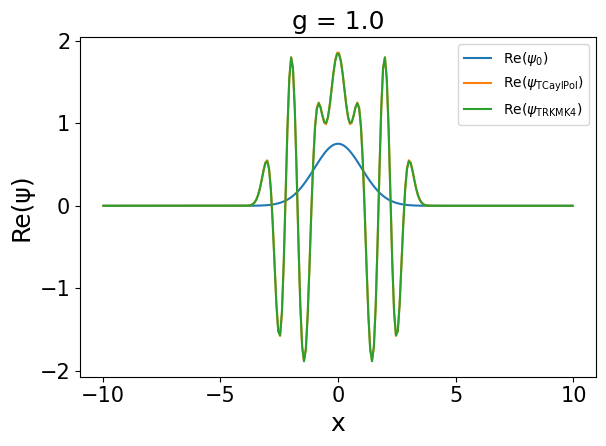

In [23]:
plt.plot(x, np.real(ψ0), label=r'$\mathrm{Re}(\psi_0)$')
plt.plot(x, np.real(psiT_cfc), label=r'$\mathrm{Re}(\psi_{\mathrm{TCaylPol}})$')
plt.plot(x, np.real(psiT_rkmk), label=r'$\mathrm{Re}(\psi_{\mathrm{TRKMK4}})$')
plt.xlabel('x'); plt.ylabel('Re(ψ)'); plt.legend(); plt.title('g = 1.0')

plt.tight_layout()
plt.savefig('GPE-sol-2-real.pdf')
plt.show()

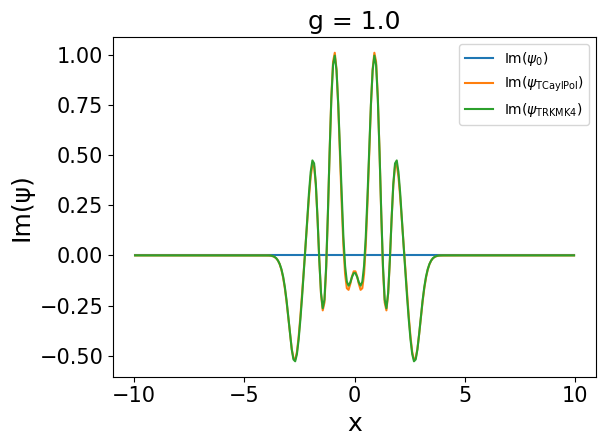

In [24]:
plt.plot(x, np.imag(ψ0), label=r'$\mathrm{Im}(\psi_0)$')
plt.plot(x, np.imag(-psiT_cfc), label=r'$\mathrm{Im}(\psi_{\mathrm{TCaylPol}})$')
plt.plot(x, np.imag(psiT_rkmk), label=r'$\mathrm{Im}(\psi_{\mathrm{TRKMK4}})$')
plt.xlabel('x'); plt.ylabel('Im(ψ)'); plt.legend(); plt.title('g = 1.0')

plt.tight_layout()
plt.savefig('GPE-sol-2-imag.pdf')
plt.show()

In [ ]:
rows = []
for g in g_set:
    psiT_cfc, t_cfc = time_one('caylpol', ψ0, g, T, N)
    psiT_rk,  t_rk  = time_one('rkmk4', ψ0, g, T, N)
    rows.append({
        "g": g,
        "CaylPol": f"{t_cfc:.3f}",
        "RKMK4": f"{t_rk:.3f}",
    })

In [ ]:
df_times = pd.DataFrame(rows)
print("\n=== Computational Time (s) for one propagation ===")
print(df_times.to_string(index=False))